In [6]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os, pickle
from collections import Counter
from pathlib import Path

In [11]:
BASE_DIR = Path().resolve().parent.parent

PRODUCTS = BASE_DIR / "data" / "processed" / "A_research_products_final.json"
CITATION = BASE_DIR / "data" / "processed" / "A_citations_merged.json"

GRAPH_DIR = BASE_DIR / "data" / "graph" / "A_graph_creation"
os.makedirs(GRAPH_DIR, exist_ok = True)

In [ ]:
with open(PRODUCTS, "r", encoding="utf-8") as f:            # Load filtered dataset
    filtered_data = json.load(f)
print(f"Filtered dataset entries: {len(filtered_data)}")

with open(CITATION, "r", encoding="utf-8") as f:            # Load citation set
    citation_set = json.load(f)
print(f"Citation set entries:     {len(citation_set)}")

id_to_data = {item["id"]: item for item in filtered_data}   # Map from id to data

G = nx.DiGraph()    # G --> Directed graph
for node_id, data in id_to_data.items():        # Nodes with attributes, marking them as part of the Unipi dataset
    G.add_node(node_id, **data, is_unipi=True)

for source, target in citation_set:             # Edges from citation set, marking them as not part of the Unipi dataset if they are new
    if source not in G:
        G.add_node(source, is_unipi=False)
    if target not in G:
        G.add_node(target, is_unipi=False)
    G.add_edge(source, target)

print("\nGraph (nodes, edges) = ({}, {})".format(G.number_of_nodes(), G.number_of_edges()))

Filtered dataset entries: 264930
Citation set entries:     8271912

Graph (nodes, edges) = (4989602, 8271912)


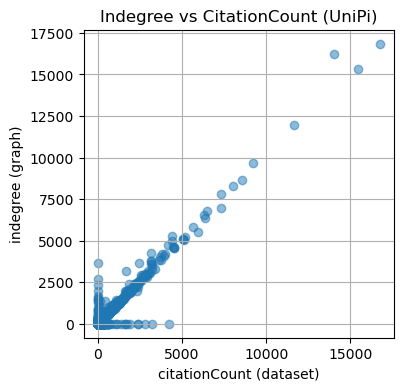

Mean absolute error between indegree and citationCount: 1.95


In [9]:
# Select all UNIPI nodes with valid indicators and citationImpact fields
unipi_nodes = [
    (node, data)
    for node, data in G.nodes(data=True)
    if data.get("is_unipi", False)
    and isinstance(data.get("indicators"), dict)
    and isinstance(data["indicators"].get("citationImpact"), dict)
]
# Extract indegree and citation counts
indegree_list = [G.in_degree(node) for node, _ in unipi_nodes]
citation_count_list = [data["indicators"]["citationImpact"].get("citationCount", 0) for _, data in unipi_nodes]

# Scatter plot
plt.figure(figsize=(4, 4))
plt.scatter(citation_count_list, indegree_list, alpha=0.5)
plt.xlabel("citationCount (dataset)")
plt.ylabel("indegree (graph)")
plt.title("Indegree vs CitationCount (UniPi)")
plt.grid(True)
plt.show()

# Mean absolute error
gaps = np.array([ind - cit for ind, cit in zip(indegree_list, citation_count_list)])
print(f"Mean absolute error between indegree and citationCount: {np.mean(np.abs(gaps)):.2f}")

In [10]:
# Drop nodes with no links
isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)
print(f"Number of isolated nodes removed: {len(isolated)}")

# Define node type helper
get_node_type = lambda n: "UNIPI" if G.nodes[n].get("is_unipi", False) else "EXT"

# Count nodes by type
node_counts = Counter(get_node_type(n) for n in G.nodes())
print(f"Nodi UNIPI: {node_counts.get('UNIPI', 0)}")
print(f"Nodi EXT:   {node_counts.get('EXT', 0)}")
print(f"Totale:     {G.number_of_nodes()}")

# Count edges by type combination
edge_counts = Counter((get_node_type(u), get_node_type(v)) for u, v in G.edges())
total_edges = G.number_of_edges() or 1

print("\nEdges grouped by node type per combination:")
for (src, tgt), count in sorted(edge_counts.items()):
    pct = count / total_edges * 100
    print(f"{src:5} -> {tgt:5}: {count:6} ({pct:.2f}%)")
print(f"{'Totale':14}: {G.number_of_edges()}")

Number of isolated nodes removed: 130302
Nodi UNIPI: 134628
Nodi EXT:   4724672
Totale:     4859300

Edges grouped by node type per combination:
EXT   -> EXT  :   8982 (0.11%)
EXT   -> UNIPI: 3955283 (47.82%)
UNIPI -> EXT  : 3918074 (47.37%)
UNIPI -> UNIPI: 389573 (4.71%)
Totale        : 8271912


In [ ]:
path = os.path.join(GRAPH_DIR, "A_source_graph.gpickle")
with open(path, "wb") as f:
    pickle.dump(G, f)